In [93]:
import pandas as pd
import numpy as np
df = pd.read_csv("..\data\Loan.csv")

df.shape
df.head()
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [94]:
df["LoanApproved"].value_counts(normalize=True)


LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64

In [95]:
df["EmploymentStatus"].value_counts()
df["LoanPurpose"].value_counts()

LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64

In [96]:
df["Age"].describe()
df["AnnualIncome"].describe()
df["LoanAmount"].describe()


count     20000.000000
mean      24882.867800
std       13427.421217
min        3674.000000
25%       15575.000000
50%       21914.500000
75%       30835.000000
max      184732.000000
Name: LoanAmount, dtype: float64

In [97]:
df["EmploymentStatus"].value_counts()
df["LoanPurpose"].value_counts()

LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64

In [98]:
df_clean=df.copy()

In [99]:
df_clean.isna().sum().sort_values(ascending=False)

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

In [100]:
df_clean.duplicated().sum()

np.int64(0)

In [101]:
df_clean["ApplicationDate"]=pd.to_datetime(df_clean["ApplicationDate"],errors="coerce")

In [102]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ApplicationDate             20000 non-null  datetime64[us]
 1   Age                         20000 non-null  int64         
 2   AnnualIncome                20000 non-null  int64         
 3   CreditScore                 20000 non-null  int64         
 4   EmploymentStatus            20000 non-null  str           
 5   EducationLevel              20000 non-null  str           
 6   Experience                  20000 non-null  int64         
 7   LoanAmount                  20000 non-null  int64         
 8   LoanDuration                20000 non-null  int64         
 9   MaritalStatus               20000 non-null  str           
 10  NumberOfDependents          20000 non-null  int64         
 11  HomeOwnershipStatus         20000 non-null  str           
 12  M

In [103]:
df_clean["LoanApproved"].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [104]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)


In [105]:
df_clean.columns

Index(['applicationdate', 'age', 'annualincome', 'creditscore',
       'employmentstatus', 'educationlevel', 'experience', 'loanamount',
       'loanduration', 'maritalstatus', 'numberofdependents',
       'homeownershipstatus', 'monthlydebtpayments',
       'creditcardutilizationrate', 'numberofopencreditlines',
       'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory',
       'loanpurpose', 'previousloandefaults', 'paymenthistory',
       'lengthofcredithistory', 'savingsaccountbalance',
       'checkingaccountbalance', 'totalassets', 'totalliabilities',
       'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth',
       'baseinterestrate', 'interestrate', 'monthlyloanpayment',
       'totaldebttoincomeratio', 'loanapproved', 'riskscore'],
      dtype='str')

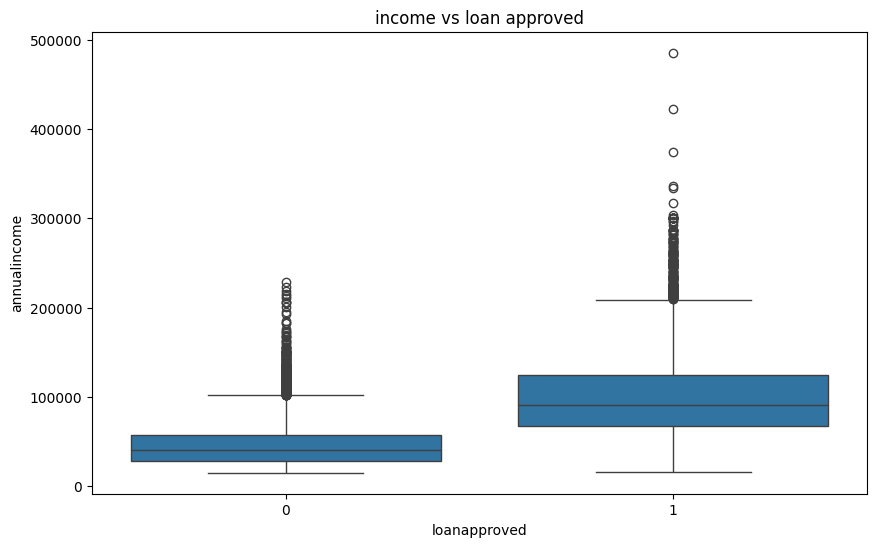

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(10,6))
sns.boxplot(y=df_clean["annualincome"],x=df_clean["loanapproved"])
plt.title("income vs loan approved")
plt.show()


In [107]:
print("loanapproved braekdown")
print(df_clean["loanapproved"].value_counts())
print("\napproval rate")
print(df_clean["loanapproved"].value_counts(normalize=True)*100)

loanapproved braekdown
loanapproved
0    15220
1     4780
Name: count, dtype: int64

approval rate
loanapproved
0    76.1
1    23.9
Name: proportion, dtype: float64


In [108]:
print(df_clean[["age","annualincome","creditscore","loanamount"]].describe())


                age   annualincome   creditscore     loanamount
count  20000.000000   20000.000000  20000.000000   20000.000000
mean      39.752600   59161.473550    571.612400   24882.867800
std       11.622713   40350.845168     50.997358   13427.421217
min       18.000000   15000.000000    343.000000    3674.000000
25%       32.000000   31679.000000    540.000000   15575.000000
50%       40.000000   48566.000000    578.000000   21914.500000
75%       48.000000   74391.000000    609.000000   30835.000000
max       80.000000  485341.000000    712.000000  184732.000000


In [109]:
print("column types:")
print(df_clean.dtypes)
print("\n")
categorical_cols=df_clean.select_dtypes(include=["object"]).columns
print(f"categorical columns:{list(categorical_cols)}")

column types:
applicationdate               datetime64[us]
age                                    int64
annualincome                           int64
creditscore                            int64
employmentstatus                         str
educationlevel                           str
experience                             int64
loanamount                             int64
loanduration                           int64
maritalstatus                            str
numberofdependents                     int64
homeownershipstatus                      str
monthlydebtpayments                    int64
creditcardutilizationrate            float64
numberofopencreditlines                int64
numberofcreditinquiries                int64
debttoincomeratio                    float64
bankruptcyhistory                      int64
loanpurpose                              str
previousloandefaults                   int64
paymenthistory                         int64
lengthofcredithistory                  in

C:\Users\KARTHICK\AppData\Local\Temp\ipykernel_14236\1468705849.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=df_clean.select_dtypes(include=["object"]).columns


In [110]:
categorical_cols=["employmentstatus","loanpurpose","maritalstatus","homeownershipstatus","educationlevel"]
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df_clean[col].value_counts())
    print(f"total unique values in {col}:{df_clean[col].nunique()}")

                  


EMPLOYMENTSTATUS:
employmentstatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64
total unique values in employmentstatus:3

LOANPURPOSE:
loanpurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64
total unique values in loanpurpose:5

MARITALSTATUS:
maritalstatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64
total unique values in maritalstatus:4

HOMEOWNERSHIPSTATUS:
homeownershipstatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64
total unique values in homeownershipstatus:4

EDUCATIONLEVEL:
educationlevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64
total unique values in educationlevel:5


In [111]:
df_encoded=df_clean.copy()
for col in categorical_cols:
    df_encoded[col]=df_encoded[col].astype("category").cat.codes
print("Encodeing complete")
print("\nBefore enccodeing (first 5 rows):")
print(df_clean[categorical_cols].head())
print("\nAfter encoding (first 5 rows):")
print(df_encoded[categorical_cols].head())



Encodeing complete

Before enccodeing (first 5 rows):
  employmentstatus         loanpurpose  ... homeownershipstatus educationlevel
0         Employed                Home  ...                 Own         Master
1         Employed  Debt Consolidation  ...            Mortgage      Associate
2         Employed           Education  ...                Rent       Bachelor
3         Employed                Home  ...            Mortgage    High School
4         Employed  Debt Consolidation  ...            Mortgage      Associate

[5 rows x 5 columns]

After encoding (first 5 rows):
   employmentstatus  loanpurpose  ...  homeownershipstatus  educationlevel
0                 0            3  ...                    2               4
1                 0            1  ...                    0               0
2                 0            2  ...                    3               1
3                 0            3  ...                    0               3
4                 0            1  ...      

In [112]:
cols_to_drop=["applicationdate","loanapproved"]
x=df_encoded.drop(columns=cols_to_drop)
y=df_encoded["loanapproved"]
print(f"features shape:{x.shape}")
print(f"targeet shape:{y.shape}")
print(f"\nFeature cols:{list(x.columns)}")

features shape:(20000, 34)
targeet shape:(20000,)

Feature cols:['age', 'annualincome', 'creditscore', 'employmentstatus', 'educationlevel', 'experience', 'loanamount', 'loanduration', 'maritalstatus', 'numberofdependents', 'homeownershipstatus', 'monthlydebtpayments', 'creditcardutilizationrate', 'numberofopencreditlines', 'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory', 'loanpurpose', 'previousloandefaults', 'paymenthistory', 'lengthofcredithistory', 'savingsaccountbalance', 'checkingaccountbalance', 'totalassets', 'totalliabilities', 'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth', 'baseinterestrate', 'interestrate', 'monthlyloanpayment', 'totaldebttoincomeratio', 'riskscore']


In [113]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {x_train.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")
print(f"\nTrain approval rate: {y_train.mean():.2%}")
print(f"Test approval rate: {y_test.mean():.2%}")


Training set: 16000 samples
Test set: 4000 samples

Train approval rate: 23.90%
Test approval rate: 23.90%


In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(x_train, y_train)
y_pred_lr = log_reg.predict(x_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.9247

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3044
           1       0.85      0.83      0.84       956

    accuracy                           0.92      4000
   macro avg       0.90      0.89      0.90      4000
weighted avg       0.92      0.92      0.92      4000



c:\Users\KARTHICK\weekly-progress\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier 
rf_model= RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train,y_train)
y_pred_rf =rf_model.predict(x_test)
accuracy_rf=accuracy_score(y_test, y_pred_rf)
print(f"Random forest accuracy: {accuracy_rf:.4f}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_rf))





Random forest accuracy: 0.9898

classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3044
           1       0.99      0.97      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.98      0.99      4000
weighted avg       0.99      0.99      0.99      4000

